# LightRAG vs. baselines — 4 datasets, **estructura por celdas** (cada RAG separado)

Escala por dataset: **20 contextos, 20 preguntas** (balanceado).

## 0. Instalación

In [13]:
%pip install -q "lightrag-hku" openai huggingface_hub jsonlines tiktoken pandas nest_asyncio networkx matplotlib

shell-init: error retrieving current directory: getcwd: cannot access parent directories: No such file or directory
shell-init: error retrieving current directory: getcwd: cannot access parent directories: No such file or directory
The folder you are executing pip from can no longer be found.


## 1. Configuración
En el panel **Secrets (🔑)** de Colab (barra izquierda) añade **dos** secretos y activa *Acceso del notebook* en ambos:
1. `OPENAI_API_KEY` → tu clave `sk-...` de OpenAI (la que ya usas).
2. `HF_TOKEN` → token gratis de **Hugging Face** (acelera la descarga del dataset). Se saca en **huggingface.co → Settings → Access Tokens → New token (tipo Read)**; copia el `hf_...` y pégalo como valor.

El `HF_TOKEN` es de Hugging Face, **no** de OpenAI: solo sirve para bajar UltraDomain más rápido y quitar el aviso amarillo.

In [14]:
import os
try:
    from google.colab import userdata
    os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY"); print("✅ Clave desde Secrets.")
except Exception:
    from getpass import getpass
    if not os.environ.get("OPENAI_API_KEY"):
        os.environ["OPENAI_API_KEY"] = getpass("Pega tu OPENAI_API_KEY: ")

# HF_TOKEN (Hugging Face) — acelera la descarga del dataset. Si lo guardaste en Secrets, se carga solo.
try:
    from google.colab import userdata as _ud
    _hf=_ud.get("HF_TOKEN")
    if _hf: os.environ["HF_TOKEN"]=_hf; print("✅ HF_TOKEN cargado (descargas más rápidas).")
except Exception:
    pass

DATASETS      = ["agriculture","cs","legal","mix"]   # los 4, siempre
MAX_CTX       = 10        # contextos por dataset (balance)
N_PREGUNTAS   = 12        # preguntas por dataset (balance)
MAX_TOKENS_CTX= 3000      # ⭐ RECORTE por contexto: indexado en SEGUNDOS (evita cientos de chunks)
MODELO        = "gpt-4o-mini"   # API OpenAI original (no cambia)
EMB_MODEL     = "text-embedding-3-small"
TOPK          = 8
GR_MAX_CHUNKS = 40        # tope de chunks del grafo GraphRAG; bájalo/súbelo aquí
USAR_DRIVE    = True

BASE="."
if USAR_DRIVE:
    from google.colab import drive; drive.mount("/content/drive")
    BASE="/content/drive/MyDrive/lightrag_ultradomain"
os.makedirs(BASE, exist_ok=True); os.chdir(BASE)
print("Trabajando en:", os.getcwd(), "| datasets:", DATASETS)

✅ Clave desde Secrets.
✅ HF_TOKEN cargado (descargas más rápidas).
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Trabajando en: /content/drive/MyDrive/lightrag_ultradomain | datasets: ['agriculture', 'cs', 'legal', 'mix']


## 2. Verificación




In [15]:
import importlib
for pkg in ["lightrag","openai","huggingface_hub","tiktoken","networkx","nest_asyncio","matplotlib"]:
    try: importlib.import_module(pkg); print(f"import {pkg}: OK")
    except Exception as e: print(f"import {pkg}: ⚠️ {e}")
from openai import OpenAI as _OA
_c=_OA()
try:
    _c.chat.completions.create(model=MODELO, messages=[{"role":"user","content":"ping"}], max_tokens=1)
    print("chat API: OK, emb dim:", len(_c.embeddings.create(model=EMB_MODEL, input=["ping"]).data[0].embedding))
    print("\n✅ Listo.")
except Exception as e: print("⚠️ API FALLA ->", e)

import lightrag: OK
import openai: OK
import huggingface_hub: OK
import tiktoken: OK
import networkx: OK
import nest_asyncio: OK
import matplotlib: OK
chat API: OK, emb dim: 1536

✅ Listo.


## 3. Utilidades comunes
Funciones base (idénticas al notebook que ya te funciona) + `preparar(CLS)`, que arma los contextos, preguntas y chunks del dataset actual en el estado `S`. Cada celda §A–§E usará `S` (los mismos chunks).

In [16]:
import time, random, re, json, glob
import numpy as np
from openai import OpenAI
from tiktoken import get_encoding
from concurrent.futures import ThreadPoolExecutor

client = OpenAI(max_retries=5)
enc = get_encoding("cl100k_base")
S = {}       # estado del dataset actual (uniq, PREG, CH, EMB, CLS)
STATS = {}   # métricas por dataset (para la tabla de eficiencia)

def _retry(fn,*a,**k):
    for t in range(6):
        try: return fn(*a,**k)
        except Exception:
            if t==5: raise
            time.sleep(min(2**t+random.random(),30))

def chat(prompt, temp=0.0, system=None):
    msgs=([{"role":"system","content":system}] if system else [])+[{"role":"user","content":prompt}]
    r=_retry(client.chat.completions.create, model=MODELO, messages=msgs, temperature=temp)
    return r.choices[0].message.content

def embed(texts):
    texts=[t if (t and t.strip()) else " " for t in texts]
    vecs=[]
    for j in range(0,len(texts),64):
        r=_retry(client.embeddings.create, model=EMB_MODEL, input=texts[j:j+64])
        vecs += [d.embedding for d in r.data]
    a=np.array(vecs,dtype=np.float32); return a/(np.linalg.norm(a,axis=1,keepdims=True)+1e-9)

def split_chunks(text, size=1200, overlap=100):
    t=enc.encode(text); out=[]; i=0
    while i<len(t):
        out.append(enc.decode(t[i:i+size])); i+=size-overlap
    return out

def retrieve(query, k=TOPK):
    v=embed([query])[0]; sims=S["EMB"]@v
    idx=np.argsort(sims)[::-1][:k]; return [S["CH"][i] for i in idx]

def gen_answer(q, ctxs):
    return chat("Answer the question using ONLY the context.\n\nContext:\n"+"\n\n".join(ctxs)+"\n\nQuestion: "+q, 0.0)

def responder_todos(fn, nombre, workers=8):
    PREG=S["PREG"]; CLS=S["CLS"]
    def _one(q):
        try: return {"query":q,"result":fn(q)}
        except Exception as e: return {"query":q,"result":f"[error: {e}]"}
    if workers>1:
        with ThreadPoolExecutor(max_workers=workers) as ex: out=list(ex.map(_one,PREG))
    else: out=[_one(q) for q in PREG]
    json.dump(out, open(f"{CLS}_{nombre}.json","w"), ensure_ascii=False)
    return out

def _mb(d): return sum(os.path.getsize(p) for p in glob.glob(os.path.join(d,"**"),recursive=True) if os.path.isfile(p))/1e6

# ---- LLM-juez (win rate en ambos órdenes) ----
DIMS=["Comprehensiveness","Diversity","Empowerment","Overall"]
SYSJ="You are an expert evaluating two answers based on Comprehensiveness, Diversity, Empowerment."
def _jp(q,a1,a2):
    return ("Evaluate two answers by: Comprehensiveness, Diversity, Empowerment; then an Overall winner.\n"
            "Question:\n"+q+"\n\nAnswer 1:\n"+str(a1)+"\n\nAnswer 2:\n"+str(a2)+"\n\n"
            'Output ONLY JSON: {"Comprehensiveness":{"Winner":"Answer 1|Answer 2"},'
            '"Diversity":{"Winner":"..."},"Empowerment":{"Winner":"..."},"Overall":{"Winner":"..."}}')
def _w(q,a1,a2):
    try:
        d=json.loads(re.search(r"\{.*\}", chat(_jp(q,a1,a2),0.0,SYSJ), re.S).group(0))
        return {k:("1" if "1" in str(d.get(k,{}).get("Winner","")) else "2") for k in DIMS}
    except Exception:
        return {k:"2" for k in DIMS}
def win_rate(fileLR, fileBase, workers=8):
    dLR=json.load(open(fileLR)); dB=json.load(open(fileBase))
    Q=[x["query"] for x in dLR]; L=[x["result"] for x in dLR]; B=[x["result"] for x in dB]
    def _pair(t):
        q,a,b=t; return _w(q,a,b), _w(q,b,a)
    with ThreadPoolExecutor(max_workers=workers) as ex:
        pares=list(ex.map(_pair, zip(Q,L,B)))
    wins={d:0 for d in DIMS}; tot=0
    for r1,r2 in pares:
        for d in DIMS: wins[d]+=(r1[d]=="1")+(r2[d]=="2")
        tot+=2
    return {d:round(100*wins[d]/tot,1) for d in DIMS}

def preparar(CLS):
    from huggingface_hub import hf_hub_download
    import jsonlines
    ruta=hf_hub_download(repo_id="TommyChien/UltraDomain", filename=f"{CLS}.jsonl", repo_type="dataset")
    seen=set(); uniq=[]
    with jsonlines.open(ruta) as r:
        for o in r:
            ctx=o.get("context")
            if ctx and ctx not in seen: seen.add(ctx); uniq.append(ctx)
    if MAX_CTX: uniq=uniq[:MAX_CTX]
    # ⭐ Recorta cada contexto a MAX_TOKENS_CTX tokens: así 1 documento gigante NO genera cientos de chunks.
    uniq=[enc.decode(enc.encode(c)[:MAX_TOKENS_CTX]) for c in uniq]
    ids=enc.encode("\n".join(uniq))
    desc=enc.decode(ids[1000:1500])+"\n"+enc.decode(ids[max(0,len(ids)-1500):max(0,len(ids)-1000)])
    n_pares=max(1,N_PREGUNTAS//5)
    pq=("Given the following description of a dataset:\n\n"+desc+"\n\n"
        f"Identify {n_pares} (user, task) combinations. For each, generate 5 questions that require a "
        "high-level understanding of the entire dataset.\n"
        "Output ONLY the questions, one per line, as: - Question N: <question>")
    txt=chat(pq,1.0)
    PREG=re.findall(r"- Question \d+:\s*(.+)", txt)[:N_PREGUNTAS]
    if len(PREG)<N_PREGUNTAS:
        PREG=(PREG+[l.strip("- ").strip() for l in txt.splitlines() if "?" in l])[:N_PREGUNTAS]
    CH=[]
    for ctx in uniq: CH+=split_chunks(ctx)
    CH=[x for x in CH if x and x.strip()]
    EMB=embed(CH)
    S.clear(); S.update(CLS=CLS, uniq=uniq, PREG=PREG, CH=CH, EMB=EMB)
    STATS.setdefault(CLS, {}).update(ctx=len(uniq), preg=len(PREG))
    print(f"  preparado {CLS}: {len(uniq)} contextos, {len(PREG)} preguntas, {len(CH)} chunks")

## §A — NaiveRAG
Recupera los k chunks más similares a la pregunta y genera. (Su propia celda.)

In [17]:
def run_naive():
    def naive_rag(q):
        return gen_answer(q, retrieve(q, k=TOPK))
    responder_todos(naive_rag, "naive")   # -> {CLS}_naive.json

## §B — RQ-RAG
Descompone la pregunta en subconsultas, recupera por cada una y genera.

In [18]:
def run_rqrag():
    def rq_rag(q):
        raw=chat("Decompose the question into up to 3 focused sub-questions. "
                 "Return ONLY a JSON list of strings.\nQuestion: "+q, 0.3)
        try: subs=json.loads(re.search(r"\[.*\]", raw, re.S).group(0))
        except Exception: subs=[q]
        ctxs=[]
        for s in subs[:3]: ctxs += retrieve(s, k=5)
        return gen_answer(q, list(dict.fromkeys(ctxs)))
    responder_todos(rq_rag, "rqrag")   # -> {CLS}_rqrag.json

## §C — HyDE
Genera un documento hipotético que responde la pregunta y recupera por su embedding.

In [19]:
def run_hyde():
    def hyde(q):
        h=chat("Write a concise passage that would answer the question.\nQuestion: "+q, 1.0)
        return gen_answer(q, retrieve(h, k=TOPK))
    responder_todos(hyde, "hyde")   # -> {CLS}_hyde.json

## §D — GraphRAG
Grafo con `networkx` (Louvain) + reportes por comunidad + búsqueda global map-reduce. (Celda propia.)

In [20]:
def run_graphrag():
    import networkx as nx
    from collections import defaultdict
    CLS=S["CLS"]; CH=S["CH"]
    def _extraer(ch):
        p=('Extract the key entities and their relationships from the text. Return ONLY JSON: '
           '{"entities":[{"name":"..","desc":".."}],"relations":[{"source":"..","target":".."}]}\n\nText:\n'+ch)
        try:
            d=json.loads(re.search(r"\{.*\}", chat(p,0.0), re.S).group(0)); return d.get("entities",[]),d.get("relations",[])
        except Exception: return [],[]
    t0=time.time(); G=nx.Graph(); ent_desc=defaultdict(list)
    with ThreadPoolExecutor(max_workers=8) as ex:
        for ents,rels in ex.map(_extraer, CH[:GR_MAX_CHUNKS]):
            for e in ents:
                n=str(e.get("name","")).strip()
                if n: ent_desc[n].append(str(e.get("desc",""))); G.add_node(n)
            for r in rels:
                s=str(r.get("source","")).strip(); t=str(r.get("target","")).strip()
                if s and t: G.add_edge(s,t)
    coms=list(nx.community.louvain_communities(G, seed=42)) if G.number_of_nodes() else []
    def _reporte(com):
        lin=[]
        for n in list(com)[:40]: lin.append("- "+n+": "+" ".join(ent_desc.get(n,[])[:2]))
        return chat("Write a concise report describing this community of related entities and its main themes.\n\n"+"\n".join(lin),0.3)
    with ThreadPoolExecutor(max_workers=8) as ex: REP=list(ex.map(_reporte, coms)) if coms else []
    S["REP"]=REP; S["REPE"]=embed(REP) if REP else None
    STATS[CLS].update(idx_gr=(time.time()-t0)/60, gr_nodes=G.number_of_nodes(), gr_edges=G.number_of_edges())
    def graphrag_ans(q):
        REP=S["REP"]; REPE=S["REPE"]
        if not REP: return "[GraphRAG sin comunidades]"
        v=embed([q])[0]; idx=np.argsort(REPE@v)[::-1][:4]; sel=[REP[i] for i in idx]
        par=[]
        for rep in sel:
            a=chat("Using ONLY this community report, give a partial answer; if not relevant reply exactly N/A.\n\nReport:\n"+rep+"\n\nQuestion: "+q,0.0)
            if a and a.strip()[:3]!="N/A": par.append(a)
        if not par: par=sel[:3]
        return chat("Combine these partial answers into ONE comprehensive answer.\n\n"+"\n\n".join(par)+"\n\nQuestion: "+q,0.0)
    responder_todos(graphrag_ans, "graphrag", workers=4)   # -> {CLS}_graphrag.json

## §E — LightRAG (el sistema propuesto)
Indexado en grafo + recuperación de doble nivel; API async (hybrid/local/global/mix). (Celda propia.)

In [21]:
async def run_lightrag():
    from lightrag import LightRAG, QueryParam
    from lightrag.llm.openai import gpt_4o_mini_complete, openai_embed
    from lightrag.kg.shared_storage import initialize_pipeline_status
    from lightrag.utils import setup_logger
    import networkx as nx
    setup_logger("lightrag", level="WARNING")
    CLS=S["CLS"]; LR_DIR=os.path.join(BASE, f"lightrag_{CLS}"); os.makedirs(LR_DIR, exist_ok=True)
    rag=LightRAG(working_dir=LR_DIR, embedding_func=openai_embed,
                 llm_model_func=gpt_4o_mini_complete, chunk_token_size=1200)
    await rag.initialize_storages(); await initialize_pipeline_status()
    t0=time.time(); await rag.ainsert(S["uniq"]); T_LR=time.time()-t0
    import asyncio as _aio
    for mode in ["hybrid","local","global"]:   # sin "mix" (no se usa en las tablas)
        tareas=[rag.aquery(q, param=QueryParam(mode=mode)) for q in S["PREG"]]
        res=await _aio.gather(*tareas, return_exceptions=True)   # todas las preguntas EN PARALELO
        out=[{"query":q,"result":(str(r) if not isinstance(r,Exception) else f"[error: {r}]")}
             for q,r in zip(S["PREG"],res)]
        json.dump(out, open(f"{CLS}_lr_{mode}.json","w"), ensure_ascii=False)
    try:
        GL=nx.read_graphml(os.path.join(LR_DIR,"graph_chunk_entity_relation.graphml")); LR_N,LR_E=GL.number_of_nodes(),GL.number_of_edges()
    except Exception: LR_N,LR_E=0,0
    STATS[CLS].update(idx_lr=T_LR/60, mb_lr=round(_mb(LR_DIR),1), lr_nodes=LR_N, lr_edges=LR_E)
    try:
        await rag.finalize_storages()   # libera el estado global de LightRAG entre datasets
    except Exception:
        pass

## §F — Evaluación (LLM-juez) por dataset
Devuelve el win rate de LightRAG vs cada baseline para el dataset actual.

In [22]:
def evaluar(CLS):
    import pandas as pd
    baselines={"NaiveRAG":f"{CLS}_naive.json","RQ-RAG":f"{CLS}_rqrag.json",
               "HyDE":f"{CLS}_hyde.json","GraphRAG":f"{CLS}_graphrag.json"}
    LR=f"{CLS}_lr_hybrid.json"
    rq1={n: win_rate(LR,p) for n,p in baselines.items() if os.path.exists(p)}
    df=pd.DataFrame(rq1).T[DIMS]
    df.to_csv(f"RQ1_{CLS}.csv")                       # guarda el resultado (para no repetir mañana)
    json.dump(STATS.get(CLS,{}), open(f"STATS_{CLS}.json","w"))
    return df

## 4. Runner — los 4 datasets, SECUENCIAL (robusto para LightRAG)
Procesa un dataset a la vez, **todo dentro de un solo event loop** (así LightRAG no da el error 'another event loop'). Reanuda: si un dataset ya tiene su `RQ1_<dataset>.csv` en Drive, lo **salta** (0 API). Así puedes completar en varias corridas sin gastar cuota de nuevo.

In [23]:
import asyncio, nest_asyncio; nest_asyncio.apply()
import pandas as pd
RES={}

async def _run_all():
    for CLS in DATASETS:
        print(f"\n########## {CLS} ##########")
        try:
            if os.path.exists(f"RQ1_{CLS}.csv"):        # ya hecho antes -> 0 llamadas API
                try: STATS[CLS]=json.load(open(f"STATS_{CLS}.json"))
                except Exception: pass
                RES[CLS]=pd.read_csv(f"RQ1_{CLS}.csv", index_col=0)
                print(f"  ↩️ {CLS} ya estaba hecho: se reutiliza (0 API)"); continue
            preparar(CLS)
            run_naive();    print("  §A NaiveRAG ok")
            run_rqrag();    print("  §B RQ-RAG ok")
            run_hyde();     print("  §C HyDE ok")
            run_graphrag(); print("  §D GraphRAG ok")
            await run_lightrag(); print("  §E LightRAG ok")   # AWAIT: mismo loop para los 4
            RES[CLS]=evaluar(CLS); print(f"  ✅ {CLS} completado")
        except Exception as e:
            print(f"  ⚠️ Falló {CLS}: {e}")

asyncio.run(_run_all())
print("\nDatasets completados:", list(RES))


########## agriculture ##########
  ↩️ agriculture ya estaba hecho: se reutiliza (0 API)

########## cs ##########
  ↩️ cs ya estaba hecho: se reutiliza (0 API)

########## legal ##########
  ↩️ legal ya estaba hecho: se reutiliza (0 API)

########## mix ##########
  ↩️ mix ya estaba hecho: se reutiliza (0 API)

Datasets completados: ['agriculture', 'cs', 'legal', 'mix']


## 5. Tabla comparativa ÚNICA (PDF + PNG) para el Beamer
Combina todo en **un solo archivo** `Comparativa_RAG_LightRAG.pdf`: panel de **calidad** (win rate promedio) y panel de **eficiencia** (indexado/grafo/almacenamiento).

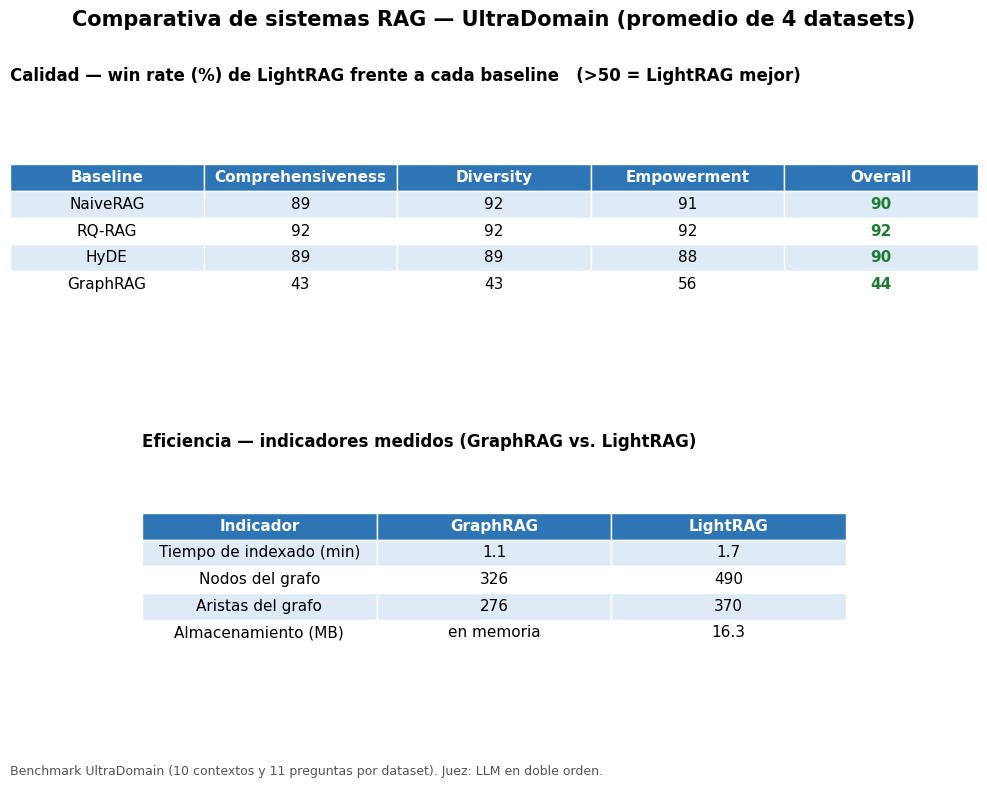


✅ ÚNICO archivo para el Beamer: /content/drive/MyDrive/lightrag_ultradomain/Comparativa_RAG_LightRAG.pdf


In [24]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

import json as _json
fr=[]; metas=[]
for cls in DATASETS:                                  # lee de DISCO: combina aunque hayas corrido en varios días
    if os.path.exists(f"RQ1_{cls}.csv"):
        d=pd.read_csv(f"RQ1_{cls}.csv", index_col=0)
        d=d.reset_index().rename(columns={d.reset_index().columns[0]:"baseline"}); d["ds"]=cls; fr.append(d)
        if os.path.exists(f"STATS_{cls}.json"):
            try: metas.append(_json.load(open(f"STATS_{cls}.json")))
            except Exception: pass
if not fr:
    raise RuntimeError("No hay resultados en disco todavía. Corre §4 primero.")
rq1=pd.concat(fr).groupby("baseline")[DIMS].mean().round(0)
orden=[b for b in ["NaiveRAG","RQ-RAG","HyDE","GraphRAG"] if b in rq1.index]; rq1=rq1.loc[orden]
def _avg(k):
    vals=[m[k] for m in metas if k in m]; return float(np.mean(vals)) if vals else 0.0
B_rows=["Tiempo de indexado (min)","Nodos del grafo","Aristas del grafo","Almacenamiento (MB)"]
B_gr=[f"{_avg('idx_gr'):.1f}", f"{_avg('gr_nodes'):.0f}", f"{_avg('gr_edges'):.0f}", "en memoria"]
B_lr=[f"{_avg('idx_lr'):.1f}", f"{_avg('lr_nodes'):.0f}", f"{_avg('lr_edges'):.0f}", f"{_avg('mb_lr'):.1f}"]

AZUL="#2E75B6"; AZULC="#DEEAF6"; VERDE="#1E7B34"; nds=len(fr)
def estilo(ax, tabla, resalta_col=None):
    tabla.auto_set_font_size(False); tabla.set_fontsize(11); tabla.scale(1,1.6)
    for (row,col),cell in tabla.get_celld().items():
        cell.set_edgecolor("white")
        if row==0: cell.set_facecolor(AZUL); cell.set_text_props(color="white", fontweight="bold")
        else: cell.set_facecolor(AZULC if row%2 else "white")
        if resalta_col is not None and col==resalta_col and row>0: cell.set_text_props(color=VERDE, fontweight="bold")

fig=plt.figure(figsize=(11,8.5)); fig.patch.set_facecolor("white")
fig.suptitle("Comparativa de sistemas RAG — UltraDomain (promedio de %d datasets)"%nds, fontsize=15, fontweight="bold", y=0.97)

axA=fig.add_axes([0.06,0.55,0.88,0.32]); axA.axis("off")
axA.set_title("Calidad — win rate (%) de LightRAG frente a cada baseline   (>50 = LightRAG mejor)", fontsize=12, fontweight="bold", loc="left", pad=10)
colsA=["Baseline"]+DIMS
datA=[[b]+[f"{rq1.loc[b,c]:.0f}" for c in DIMS] for b in rq1.index]
tA=axA.table(cellText=datA, colLabels=colsA, loc="center", cellLoc="center"); estilo(axA,tA, resalta_col=len(colsA)-1)

axB=fig.add_axes([0.18,0.16,0.64,0.28]); axB.axis("off")
axB.set_title("Eficiencia — indicadores medidos (GraphRAG vs. LightRAG)", fontsize=12, fontweight="bold", loc="left", pad=10)
datB=[[B_rows[i],B_gr[i],B_lr[i]] for i in range(len(B_rows))]
tB=axB.table(cellText=datB, colLabels=["Indicador","GraphRAG","LightRAG"], loc="center", cellLoc="center"); estilo(axB,tB, resalta_col=None)

fig.text(0.06,0.07,"Benchmark UltraDomain (%d contextos y %d preguntas por dataset). Juez: LLM en doble orden."%(int(_avg('ctx')),int(_avg('preg'))), fontsize=9, color="#555555")

PDF="Comparativa_RAG_LightRAG.pdf"; PNG="Comparativa_RAG_LightRAG.png"
with PdfPages(PDF) as pp: pp.savefig(fig, bbox_inches="tight")
fig.savefig(PNG, dpi=160, bbox_inches="tight")
plt.show()
print("\n✅ ÚNICO archivo para el Beamer:", os.path.abspath(PDF))